# ANNs Explained — from a single neuron to Transformers, GNNs and GANs

Implementation companion to [`ANN_Cheatsheet.md`](ANN_Cheatsheet.md). Each section implements,
trains, and **visualizes** one concept from the cheat sheet, in the same order: shared
foundations first, then one section per architecture family. Every architecture section ends
with an explicit **takeaway** — a printed number or a plot designed to make the point
unambiguous, not just "look at the pretty picture."

**Contents**

1. Setup
2. Foundations — activation functions
3. Foundations — bias–variance trade-off
4. Foundations — batch vs. online learning
5. Feedforward NN (FNN/MLP): shallow vs. deep, on two moons
6. Convolutional NN (CNN): filters and feature maps
7. Recurrent NNs: why gating (LSTM/GRU) beats vanilla RNN
8. Transformers: a trained, interpretable self-attention example
9. Autoencoders: compressing images through a bottleneck
10. Variational Autoencoders: from compression to generation
11. GANs: adversarially generating the two-moons distribution
12. Graph Neural Networks: classifying nodes from graph structure alone
13. Embeddings: categories becoming vectors
14. Recap


## 1. Setup

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits, make_moons
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 100


## 2. Foundations — activation functions

Every neuron computes a weighted sum of its inputs (`z = w . x + b`) and passes it through a
non-linear **activation function**. Without that non-linearity, stacking layers would still only
ever produce a linear function of the input — depth would be pointless, regardless of
architecture.

We plot the three classic functions and their **derivatives**: sigmoid/tanh flatten out
(saturate) for large |x|, so gradients shrink to ~0 there. That's the *vanishing gradient*
problem — it's why ReLU is the default for hidden layers below, and why the RNN section (§7)
needs gated cells (LSTM/GRU) to cope with it over long sequences.


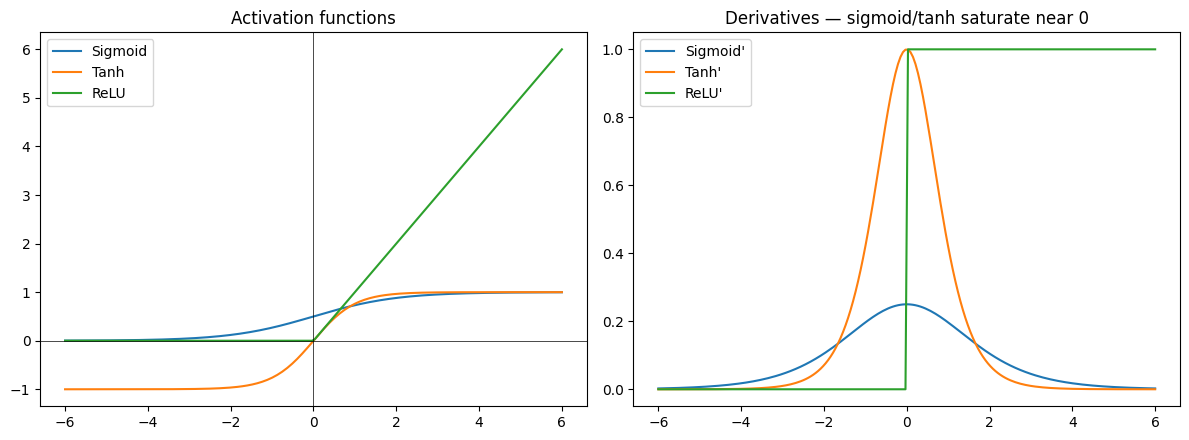

Takeaway: past |x|~3, sigmoid'/tanh' are almost exactly 0 -> almost no gradient signal
reaches earlier layers through a saturated unit. ReLU' is a constant 1 for any x > 0.


In [2]:
x = torch.linspace(-6, 6, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(x, torch.sigmoid(x), label="Sigmoid")
axes[0].plot(x, torch.tanh(x), label="Tanh")
axes[0].plot(x, torch.relu(x), label="ReLU")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].axvline(0, color="black", linewidth=0.5)
axes[0].set_title("Activation functions")
axes[0].legend()


def grad_of(f):
    x_grad = torch.linspace(-6, 6, 200, requires_grad=True)
    y = f(x_grad)
    (g,) = torch.autograd.grad(y, x_grad, grad_outputs=torch.ones_like(y))
    return g.detach()


axes[1].plot(x, grad_of(torch.sigmoid), label="Sigmoid'")
axes[1].plot(x, grad_of(torch.tanh), label="Tanh'")
axes[1].plot(x, grad_of(torch.relu), label="ReLU'")
axes[1].set_title("Derivatives — sigmoid/tanh saturate near 0")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Takeaway: past |x|~3, sigmoid'/tanh' are almost exactly 0 -> almost no gradient signal")
print("reaches earlier layers through a saturated unit. ReLU' is a constant 1 for any x > 0.")


## 3. Foundations — bias–variance trade-off

We fit the *same small-network architecture*, varying only its **width** (number of neurons), to
a noisy sine curve, and look at train vs. test error:

- too few neurons → **underfits** (high bias): can't capture the curve even on training data —
  train and test error are both high, and close together.
- a well-sized network → fits the true signal, generalizes to held-out points — both errors are
  low.
- way too many neurons + long training → **overfits** (high variance): chases the noise — train
  error keeps dropping, but test error doesn't (or gets worse). A widening train/test gap **is**
  the definition of overfitting; the printed numbers below make that gap explicit.


In [3]:
def true_fn(x):
    return np.sin(2 * np.pi * x)


rng = np.random.RandomState(SEED)
x_all = rng.uniform(0, 1, 30)
y_all = true_fn(x_all) + rng.normal(0, 0.2, size=x_all.shape)
x_train_bv, x_test_bv, y_train_bv, y_test_bv = train_test_split(
    x_all, y_all, test_size=0.3, random_state=SEED
)

Xtr_bv = torch.tensor(x_train_bv, dtype=torch.float32).unsqueeze(1)
ytr_bv = torch.tensor(y_train_bv, dtype=torch.float32).unsqueeze(1)
Xte_bv = torch.tensor(x_test_bv, dtype=torch.float32).unsqueeze(1)
yte_bv = torch.tensor(y_test_bv, dtype=torch.float32).unsqueeze(1)


def make_regressor(n_neurons):
    return nn.Sequential(
        nn.Linear(1, n_neurons), nn.Tanh(),
        nn.Linear(n_neurons, n_neurons), nn.Tanh(),
        nn.Linear(n_neurons, 1),
    )


configs = {"Underfit (2 neurons)": 2, "Good fit (16 neurons)": 16, "Overfit (256 neurons)": 256}
results = {}
for name, n in configs.items():
    torch.manual_seed(SEED)
    model = make_regressor(n)
    opt = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()
    for _ in range(12000):  # small/cheap problem, but the 256-neuron net needs this many steps to actually start memorizing noise
        opt.zero_grad()
        loss = loss_fn(model(Xtr_bv), ytr_bv)
        loss.backward()
        opt.step()
    with torch.no_grad():
        train_err = loss_fn(model(Xtr_bv), ytr_bv).item()
        test_err = loss_fn(model(Xte_bv), yte_bv).item()
    results[name] = (model, train_err, test_err)


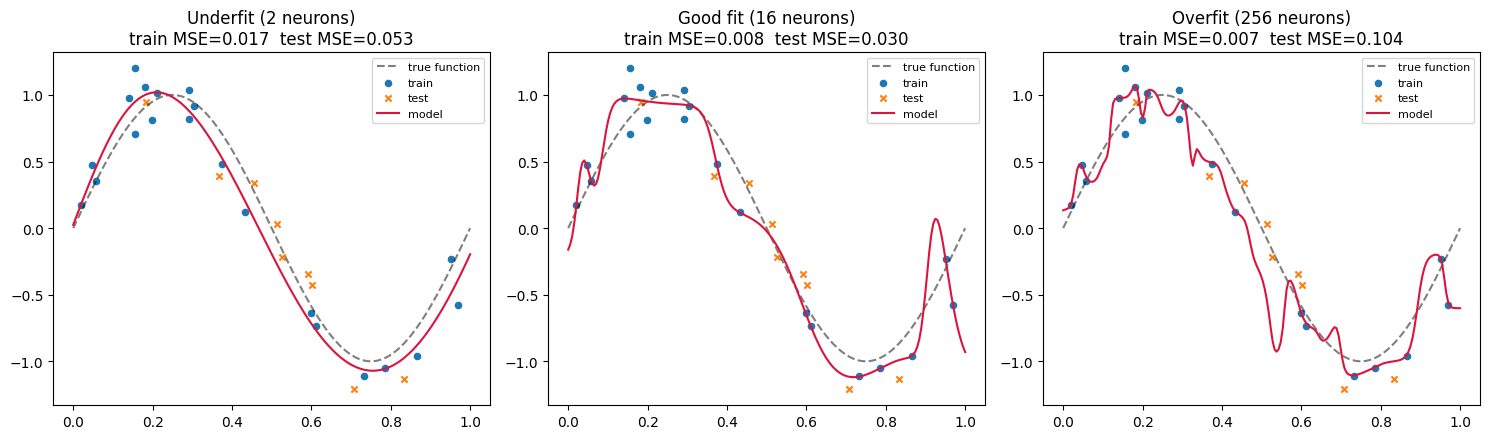

config                  train MSE   test MSE  test-train gap
Underfit (2 neurons)        0.017      0.053          +0.036
Good fit (16 neurons)       0.008      0.030          +0.022
Overfit (256 neurons)       0.007      0.104          +0.097

Takeaway: underfit has both errors high & close; overfit has a low train error but a
large positive gap to test error. The good fit keeps both low AND close.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
x_plot = torch.linspace(0, 1, 200).unsqueeze(1)

for ax, (name, (model, train_err, test_err)) in zip(axes, results.items()):
    with torch.no_grad():
        y_plot = model(x_plot)
    ax.plot(x_plot, true_fn(x_plot.numpy()), "k--", label="true function", alpha=0.5)
    ax.scatter(x_train_bv, y_train_bv, label="train", s=20)
    ax.scatter(x_test_bv, y_test_bv, label="test", s=20, marker="x")
    ax.plot(x_plot, y_plot, color="crimson", label="model")
    ax.set_title(f"{name}\ntrain MSE={train_err:.3f}  test MSE={test_err:.3f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"{'config':22s} {'train MSE':>10s} {'test MSE':>10s} {'test-train gap':>15s}")
for name, (_, train_err, test_err) in results.items():
    print(f"{name:22s} {train_err:10.3f} {test_err:10.3f} {test_err - train_err:+15.3f}")
print("\nTakeaway: underfit has both errors high & close; overfit has a low train error but a")
print("large positive gap to test error. The good fit keeps both low AND close.")


## 4. Foundations — batch vs. online learning

Same architecture, same number of passes over the data (epochs) — the only difference is how many
examples are used per weight update (`batch_size`):

- **Batch learning**: `batch_size = N` — one update per epoch, using the whole dataset.
- **Online learning**: `batch_size = 1` — one update per example, i.e. many more (noisier) updates
  per epoch.

We train both on the two-moons classification task (introduced properly in §5) and compare not
just the loss curves but the actual **test-set accuracy** each converges to, so the difference is
a number, not just a vibe from two similarly-shaped curves.


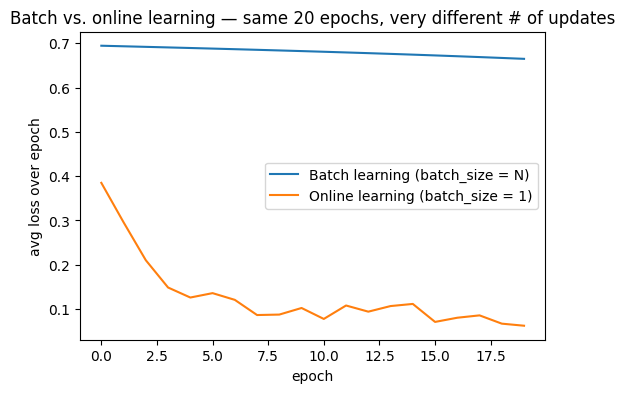

Batch learning:  1 update/epoch   -> test accuracy = 65.0%
Online learning: 400 updates/epoch -> test accuracy = 95.0%

Takeaway: with the same epoch budget, online learning does ~N times more weight updates,
so it can converge faster wall-clock-wise — at the cost of noisier, less stable updates.


In [5]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.2, random_state=SEED)
X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=SEED
)
moons_scaler = StandardScaler().fit(X_moons_train)
X_moons_train_s = moons_scaler.transform(X_moons_train)
X_moons_test_s = moons_scaler.transform(X_moons_test)

Xtr = torch.tensor(X_moons_train_s, dtype=torch.float32)
ytr = torch.tensor(y_moons_train, dtype=torch.float32).unsqueeze(1)
Xte = torch.tensor(X_moons_test_s, dtype=torch.float32)
yte = torch.tensor(y_moons_test, dtype=torch.float32).unsqueeze(1)


class FeedForwardNN(nn.Module):
    def __init__(self, n_hidden_layers, n_neurons):
        super().__init__()
        layers = []
        in_dim = 2
        for _ in range(n_hidden_layers):
            layers += [nn.Linear(in_dim, n_neurons), nn.ReLU()]
            in_dim = n_neurons
        layers += [nn.Linear(in_dim, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def accuracy(model, X, y):
    with torch.no_grad():
        preds = (torch.sigmoid(model(X)) > 0.5).float()
    return (preds == y).float().mean().item()


def train_with_batch_size(batch_size, epochs=20):
    torch.manual_seed(SEED)
    model = FeedForwardNN(n_hidden_layers=2, n_neurons=8)
    opt = optim.SGD(model.parameters(), lr=0.1)
    loss_fn = nn.BCEWithLogitsLoss()
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)

    losses = []
    for _ in range(epochs):
        epoch_losses = []
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            epoch_losses.append(loss.item())
        losses.append(np.mean(epoch_losses))
    return model, losses


batch_model, batch_losses = train_with_batch_size(batch_size=len(Xtr))  # batch learning
online_model, online_losses = train_with_batch_size(batch_size=1)  # online learning

plt.figure(figsize=(6, 4))
plt.plot(batch_losses, label="Batch learning (batch_size = N)")
plt.plot(online_losses, label="Online learning (batch_size = 1)")
plt.xlabel("epoch")
plt.ylabel("avg loss over epoch")
plt.title("Batch vs. online learning — same 20 epochs, very different # of updates")
plt.legend()
plt.show()

print(f"Batch learning:  1 update/epoch   -> test accuracy = {accuracy(batch_model, Xte, yte):.1%}")
print(f"Online learning: {len(Xtr)} updates/epoch -> test accuracy = {accuracy(online_model, Xte, yte):.1%}")
print("\nTakeaway: with the same epoch budget, online learning does ~N times more weight updates,")
print("so it can converge faster wall-clock-wise — at the cost of noisier, less stable updates.")


## 5. Feedforward NN (FNN/MLP): shallow vs. deep

A **feedforward network** stacks dense layers with non-linear activations; information only flows
forward. We fit a **shallow** net (1 hidden layer) and a **deep** net (4 hidden layers) to the
same non-linearly-separable two-moons dataset used in §4, and compare the decision boundary each
learns.


In [6]:
def train_model(model, X, y, epochs=300, lr=0.05):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    losses = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses


torch.manual_seed(SEED)
shallow = FeedForwardNN(n_hidden_layers=1, n_neurons=4)
losses_shallow = train_model(shallow, Xtr, ytr)

torch.manual_seed(SEED)
deep = FeedForwardNN(n_hidden_layers=4, n_neurons=16)
losses_deep = train_model(deep, Xtr, ytr)

print(f"shallow: {sum(p.numel() for p in shallow.parameters())} params, test acc = {accuracy(shallow, Xte, yte):.1%}")
print(f"deep:    {sum(p.numel() for p in deep.parameters())} params, test acc = {accuracy(deep, Xte, yte):.1%}")


shallow: 17 params, test acc = 99.0%
deep:    881 params, test acc = 95.0%


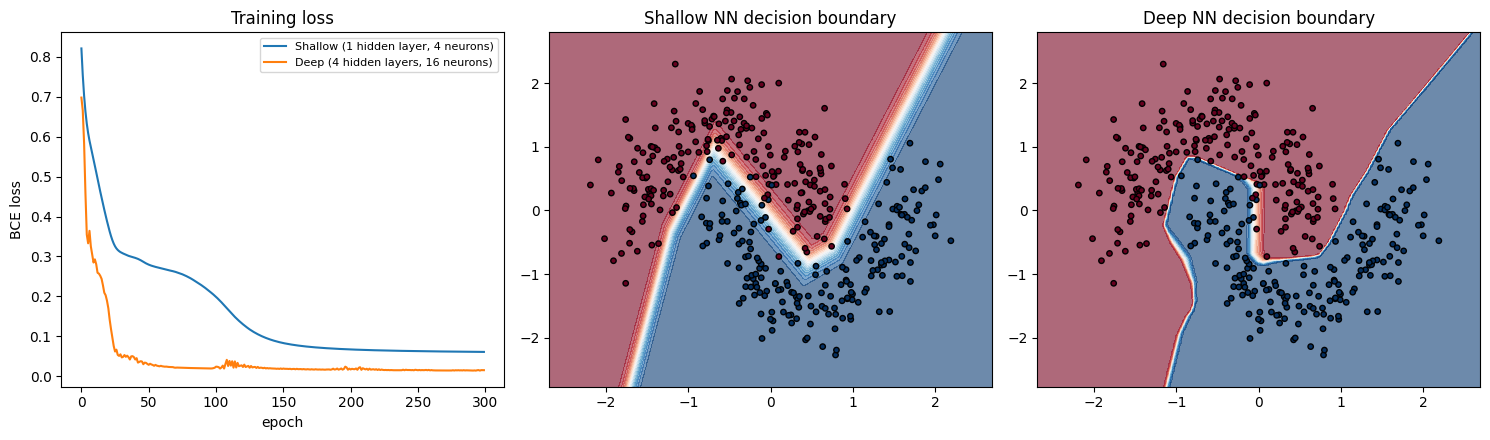

Takeaway: both separate the moons reasonably, but the deep net's extra layers let it carve
a boundary that hugs the crescent shapes much more tightly than the shallow net's near-linear cut.


In [7]:
def plot_decision_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        probs = torch.sigmoid(model(grid)).reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=20, cmap="RdBu", alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="RdBu", edgecolor="k", s=15)
    ax.set_title(title)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(losses_shallow, label="Shallow (1 hidden layer, 4 neurons)")
axes[0].plot(losses_deep, label="Deep (4 hidden layers, 16 neurons)")
axes[0].set_title("Training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].legend(fontsize=8)

plot_decision_boundary(axes[1], shallow, X_moons_train_s, y_moons_train, "Shallow NN decision boundary")
plot_decision_boundary(axes[2], deep, X_moons_train_s, y_moons_train, "Deep NN decision boundary")
plt.tight_layout()
plt.show()

print("Takeaway: both separate the moons reasonably, but the deep net's extra layers let it carve")
print("a boundary that hugs the crescent shapes much more tightly than the shallow net's near-linear cut.")


## 6. Convolutional NN (CNN): filters and feature maps

An MLP on an image has to flatten it into a vector, throwing away the fact that nearby pixels are
related. A CNN instead slides small learned **filters (kernels)** across the image, and — because
the *same* filter is reused at every location — it needs far fewer parameters and detects a
pattern wherever it appears.

We train a tiny CNN and an MLP with a comparable parameter budget on the same task (classifying
8x8 handwritten digit images into 10 classes), then look **inside** the CNN at what its first-layer
filters and the feature maps they produce actually look like.


In [8]:
digits = load_digits()
X_dig = digits.data.astype(np.float32) / 16.0  # scale pixel values to [0, 1]
y_dig = digits.target

X_dig_train, X_dig_test, y_dig_train, y_dig_test = train_test_split(
    X_dig, y_dig, test_size=0.2, random_state=SEED, stratify=y_dig
)
Xdig_tr = torch.tensor(X_dig_train)
Xdig_te = torch.tensor(X_dig_test)
ydig_tr = torch.tensor(y_dig_train, dtype=torch.long)
ydig_te = torch.tensor(y_dig_test, dtype=torch.long)

Xdig_tr_img = Xdig_tr.view(-1, 1, 8, 8)
Xdig_te_img = Xdig_te.view(-1, 1, 8, 8)


class SimpleCNN(nn.Module):
    def __init__(self, n_filters1=8, n_filters2=16):
        super().__init__()
        self.conv1 = nn.Conv2d(1, n_filters1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_filters1, n_filters2, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(n_filters2 * 2 * 2, 10)

    def forward(self, x):
        f1 = self.pool(torch.relu(self.conv1(x)))  # 8x8 -> 4x4
        f2 = self.pool(torch.relu(self.conv2(f1)))  # 4x4 -> 2x2
        return self.fc(f2.flatten(1))

    def feature_maps(self, x):
        f1 = torch.relu(self.conv1(x))
        return f1


class SimpleMLP(nn.Module):
    def __init__(self, hidden=24):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(64, hidden), nn.ReLU(), nn.Linear(hidden, 10))

    def forward(self, x):
        return self.net(x.flatten(1))


def train_classifier(model, X, y, epochs=200, lr=0.01):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
    return model


def clf_accuracy(model, X, y):
    with torch.no_grad():
        preds = model(X).argmax(1)
    return (preds == y).float().mean().item()


torch.manual_seed(SEED)
cnn = train_classifier(SimpleCNN(), Xdig_tr_img, ydig_tr)
torch.manual_seed(SEED)
mlp = train_classifier(SimpleMLP(), Xdig_tr_img, ydig_tr)

print(f"CNN: {sum(p.numel() for p in cnn.parameters())} params, test acc = {clf_accuracy(cnn, Xdig_te_img, ydig_te):.1%}")
print(f"MLP: {sum(p.numel() for p in mlp.parameters())} params, test acc = {clf_accuracy(mlp, Xdig_te_img, ydig_te):.1%}")


CNN: 1898 params, test acc = 97.5%
MLP: 1810 params, test acc = 96.4%


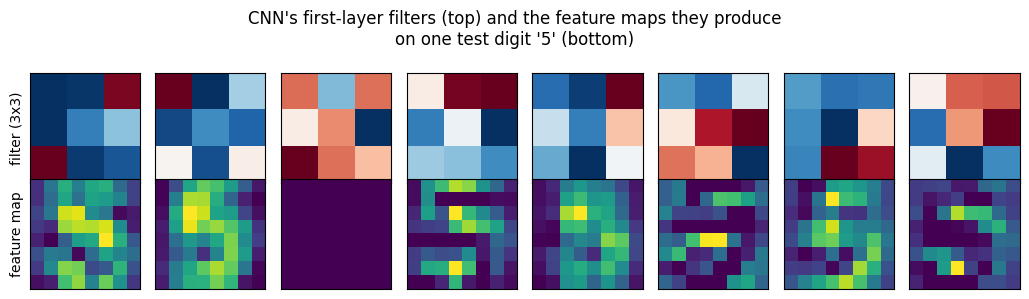

Takeaway: each filter reacts differently to the same input image — some fire on strokes
in one orientation, some on curves — that's the CNN building reusable local detectors
instead of the MLP's one-giant-weight-per-pixel approach.


In [9]:
with torch.no_grad():
    filters = cnn.conv1.weight[:, 0].numpy()  # (n_filters1, 3, 3)
    sample_img = Xdig_te_img[0:1]
    feature_maps = cnn.feature_maps(sample_img)[0].numpy()  # (n_filters1, 8, 8)

n_filters = filters.shape[0]
fig, axes = plt.subplots(2, n_filters, figsize=(1.3 * n_filters, 3))

for i in range(n_filters):
    axes[0, i].imshow(filters[i], cmap="RdBu")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    axes[1, i].imshow(feature_maps[i], cmap="viridis")
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
axes[0, 0].set_ylabel("filter (3x3)")
axes[1, 0].set_ylabel("feature map")
plt.suptitle(f"CNN's first-layer filters (top) and the feature maps they produce\non one test digit '{y_dig_test[0]}' (bottom)")
plt.tight_layout()
plt.show()

print("Takeaway: each filter reacts differently to the same input image — some fire on strokes")
print("in one orientation, some on curves — that's the CNN building reusable local detectors")
print("instead of the MLP's one-giant-weight-per-pixel approach.")


## 7. Recurrent NNs: why gating (LSTM/GRU) beats vanilla RNN

RNNs keep a hidden state that's updated at every time step. To make the gap between vanilla RNNs
and gated variants (LSTM/GRU) obvious, we use a task specifically designed to require **long-range
memory**: each input sequence is 30 steps of random noise, except a single "signal" value planted
near the very start (position 3). The model only sees the whole sequence and must output that
early signal value — so it has to carry it, unchanged, through ~27 steps of irrelevant noise. This
is the same failure mode (vanishing gradients over many steps) that motivated LSTM's gates.

> This cell trains 3 models for 800 epochs each with mini-batch gradient descent (needed for the
> vanilla RNN's failure to show up reliably) — it takes **~3-4 minutes** on CPU, the slowest cell
> in this notebook.


In [10]:
def make_long_range_dataset(seq_len=30, n_samples=1500, signal_pos=3):
    rng = np.random.RandomState(SEED)
    X = rng.uniform(-1, 1, size=(n_samples, seq_len, 1)).astype(np.float32)
    y = X[:, signal_pos, :].copy()  # target = value planted near the start, everything else is noise
    return torch.tensor(X), torch.tensor(y)


X_seq, y_seq = make_long_range_dataset()
n_train = 1200
X_seq_train, y_seq_train = X_seq[:n_train], y_seq[:n_train]
X_seq_test, y_seq_test = X_seq[n_train:], y_seq[n_train:]


class SequenceModel(nn.Module):
    def __init__(self, cell_type="RNN", hidden_size=32):
        super().__init__()
        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[cell_type]
        self.rnn = rnn_cls(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])  # prediction from the last time step


def train_sequence_model(cell_type, epochs=800, lr=0.005, batch_size=64, clip=1.0):
    torch.manual_seed(SEED)
    model = SequenceModel(cell_type)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    n = len(X_seq_train)
    losses = []
    for _ in range(epochs):
        perm = torch.randperm(n)
        epoch_losses = []
        for i in range(0, n, batch_size):
            idx = perm[i : i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X_seq_train[idx]), y_seq_train[idx])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)  # avoids exploding-gradient blowups
            opt.step()
            epoch_losses.append(loss.item())
        losses.append(np.mean(epoch_losses))
    return model, losses


models_seq, losses_seq = {}, {}
for cell in ["RNN", "LSTM", "GRU"]:
    models_seq[cell], losses_seq[cell] = train_sequence_model(cell)

# baseline: always predicting 0 (the mean of Uniform(-1, 1))
baseline_mse = (y_seq_test ** 2).mean().item()
print(f"'always predict 0' baseline MSE: {baseline_mse:.4f}  (a model that learned nothing scores about this)")
for cell, model in models_seq.items():
    with torch.no_grad():
        test_mse = nn.functional.mse_loss(model(X_seq_test), y_seq_test).item()
    print(f"{cell:5s} test MSE = {test_mse:.6f}")


'always predict 0' baseline MSE: 0.3634  (a model that learned nothing scores about this)
RNN   test MSE = 0.361472
LSTM  test MSE = 0.000029
GRU   test MSE = 0.000186


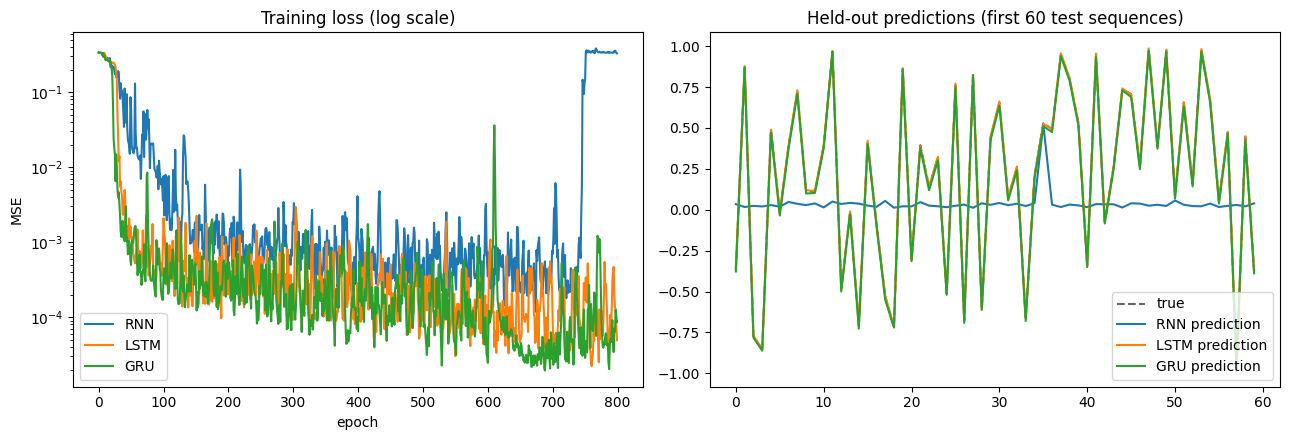

Takeaway: recalling a value from 27 steps back is exactly the setting vanishing gradients
break vanilla RNNs on -- its test MSE lands right on the 'learned nothing' baseline. LSTM/GRU's
gates let gradients (and the signal itself) skip through time steps mostly unchanged, landing
several orders of magnitude closer to a perfect 0.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for cell, l in losses_seq.items():
    axes[0].plot(l, label=cell)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")
axes[0].set_title("Training loss (log scale)")
axes[0].legend()

axes[1].plot(y_seq_test[:60].numpy().ravel(), "k--", label="true", alpha=0.6)
with torch.no_grad():
    for cell, m in models_seq.items():
        axes[1].plot(m(X_seq_test[:60]).numpy().ravel(), label=f"{cell} prediction")
axes[1].set_title("Held-out predictions (first 60 test sequences)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Takeaway: recalling a value from 27 steps back is exactly the setting vanishing gradients")
print("break vanilla RNNs on -- its test MSE lands right on the 'learned nothing' baseline. LSTM/GRU's")
print("gates let gradients (and the signal itself) skip through time steps mostly unchanged, landing")
print("several orders of magnitude closer to a perfect 0.")


## 8. Transformers: a trained, interpretable self-attention example

Self-attention lets every position in a sequence directly look at every other position — no
step-by-step bottleneck like an RNN. To make the mechanism concrete (not just an equation), we
train a real `nn.TransformerEncoderLayer` (genuine multi-head self-attention + feed-forward, the
actual building block of BERT/GPT-style models) on a task where we can verify *exactly* what it
should be attending to: **given a sequence of numbers, find the position of the largest one.**

Each position outputs one logit (via a shared linear head on top of the encoder), and we train
those `seq_len` logits as a classification over "which position is the max" — a pointer-style use
of a Transformer encoder. Because finding the max doesn't depend on order, we deliberately skip
positional encoding here (it's normally added when order *does* matter, e.g. for language).


In [12]:
class TinyTransformer(nn.Module):
    def __init__(self, embed_dim=16, n_heads=2):
        super().__init__()
        self.input_proj = nn.Linear(1, embed_dim)
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=32, batch_first=True
        )
        self.out_proj = nn.Linear(embed_dim, 1)

    def forward(self, x):
        h = self.input_proj(x)  # (batch, seq_len, embed_dim)
        h = self.encoder_layer(h)  # self-attention + FFN, still (batch, seq_len, embed_dim)
        return self.out_proj(h).squeeze(-1)  # (batch, seq_len) -> one logit per position

    def attention_weights(self, x):
        h = self.input_proj(x)
        _, weights = self.encoder_layer.self_attn(
            h, h, h, need_weights=True, average_attn_weights=False
        )
        return weights  # (batch, n_heads, seq_len, seq_len)


def make_find_max_dataset(seq_len=10, n_samples=3000):
    rng = np.random.RandomState(SEED)
    X = rng.uniform(-1, 1, size=(n_samples, seq_len, 1)).astype(np.float32)
    y = X[:, :, 0].argmax(axis=1)
    return torch.tensor(X), torch.tensor(y, dtype=torch.long)


X_attn, y_attn = make_find_max_dataset()
n_train_attn = 2400
X_attn_train, y_attn_train = X_attn[:n_train_attn], y_attn[:n_train_attn]
X_attn_test, y_attn_test = X_attn[n_train_attn:], y_attn[n_train_attn:]

torch.manual_seed(SEED)
attn_model = TinyTransformer()
opt = optim.Adam(attn_model.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()
attn_losses = []
for _ in range(300):
    opt.zero_grad()
    logits = attn_model(X_attn_train)
    loss = loss_fn(logits, y_attn_train)
    loss.backward()
    opt.step()
    attn_losses.append(loss.item())

with torch.no_grad():
    test_logits = attn_model(X_attn_test)
    test_acc = (test_logits.argmax(1) == y_attn_test).float().mean().item()
print(f"Test accuracy at finding the position of the max value (chance = 10%): {test_acc:.1%}")


Test accuracy at finding the position of the max value (chance = 10%): 96.5%


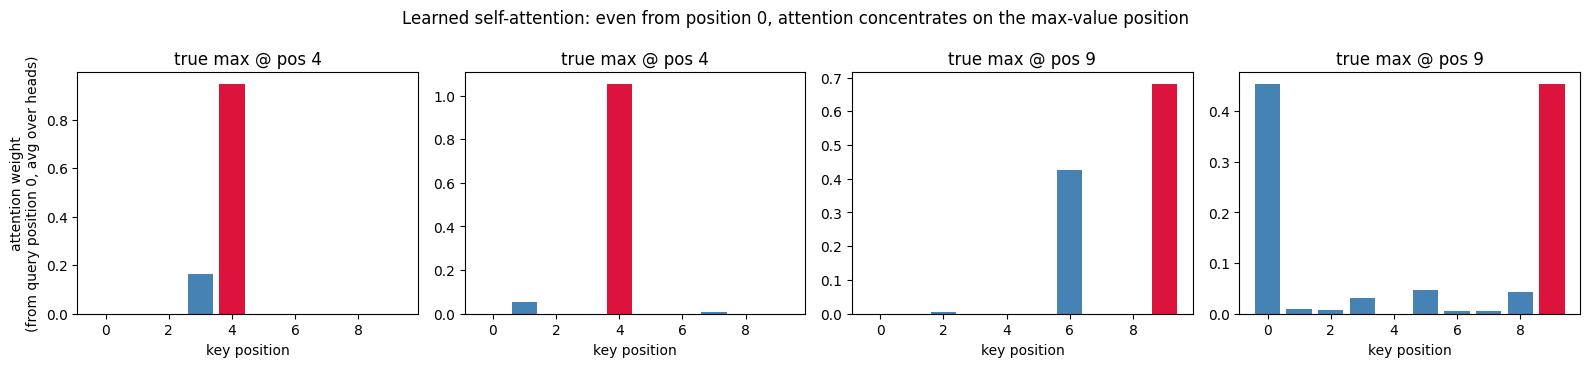

Takeaway: with random, untrained weights these bars would be ~flat (uniform 1/seq_len).
After training on the actual task, attention sharply prefers the correct position, and the
model gets 96% of held-out sequences right — the mechanism is doing real work, not decoration.


In [13]:
with torch.no_grad():
    example_x = X_attn_test[:4]
    example_weights = attn_model.attention_weights(example_x)  # (4, n_heads, seq_len, seq_len)

seq_len = example_x.shape[1]
n_heads = example_weights.shape[1]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.7))
for i, ax in enumerate(axes):
    true_idx = y_attn_test[i].item()
    # average across heads for a single, readable bar chart per example
    weights = example_weights[i].mean(dim=0)[0].numpy()  # attention *from* position 0, to all positions
    colors = ["crimson" if j == true_idx else "steelblue" for j in range(seq_len)]
    ax.bar(range(seq_len), weights, color=colors)
    ax.set_title(f"true max @ pos {true_idx}")
    ax.set_xlabel("key position")
axes[0].set_ylabel("attention weight\n(from query position 0, avg over heads)")
plt.suptitle("Learned self-attention: even from position 0, attention concentrates on the max-value position")
plt.tight_layout()
plt.show()

print("Takeaway: with random, untrained weights these bars would be ~flat (uniform 1/seq_len).")
print(f"After training on the actual task, attention sharply prefers the correct position, and the")
print(f"model gets {test_acc:.0%} of held-out sequences right — the mechanism is doing real work, not decoration.")


## 9. Autoencoders: compressing images through a bottleneck

An autoencoder learns to reconstruct its own input through a low-dimensional **bottleneck**,
forcing it to discover a compressed representation. We compress the same 8x8 digit images from §6
(64 pixels) down to just **2 numbers** and back, then look at the reconstructions and the 2D
latent space those 2 numbers form.


In [14]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=64, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 32), nn.ReLU(), nn.Linear(32, latent_dim))
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(), nn.Linear(32, input_dim), nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


torch.manual_seed(SEED)
ae = Autoencoder()
opt = optim.Adam(ae.parameters(), lr=0.01)
loss_fn = nn.MSELoss()
ae_losses = []
for _ in range(300):
    opt.zero_grad()
    recon, _ = ae(Xdig_tr)
    loss = loss_fn(recon, Xdig_tr)
    loss.backward()
    opt.step()
    ae_losses.append(loss.item())

with torch.no_grad():
    recon_test, latent_test = ae(Xdig_te)

print(f"Final reconstruction MSE: {ae_losses[-1]:.4f} (pixels scaled to [0, 1])")


Final reconstruction MSE: 0.0359 (pixels scaled to [0, 1])


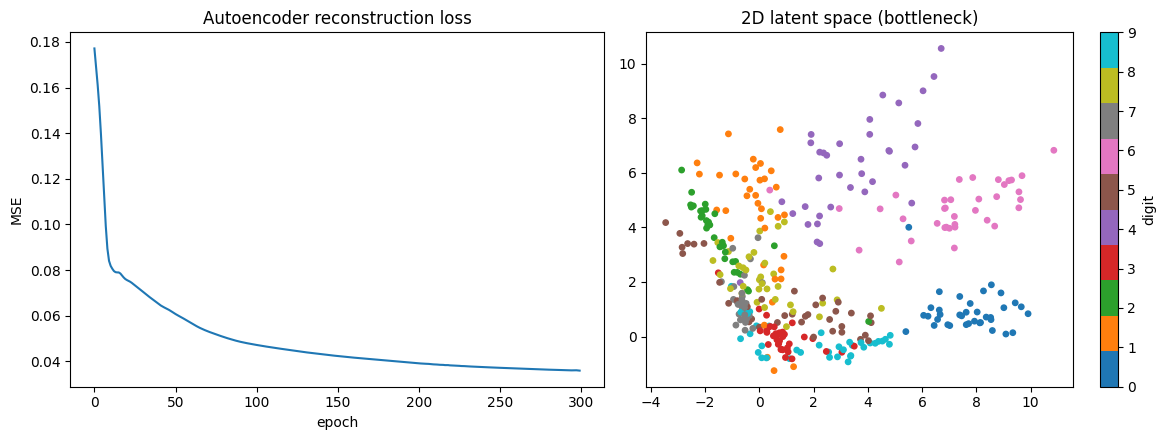

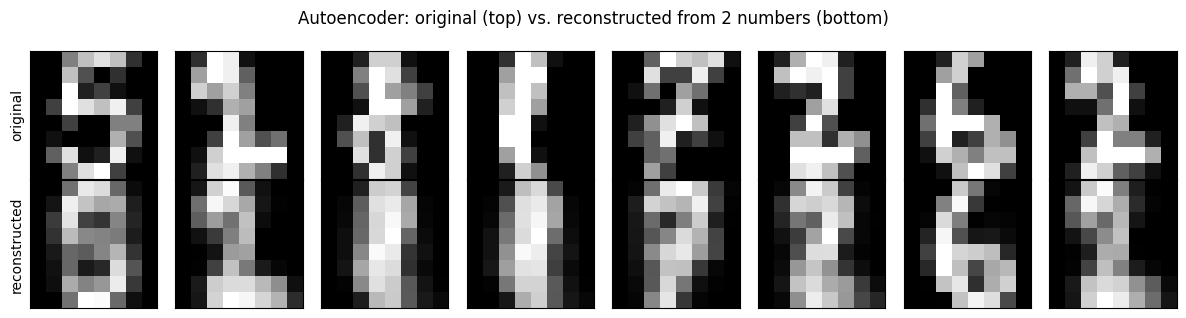

Takeaway: digits of the same class cluster together in the 2D latent space even though the
network was never given the labels — reconstruction alone forced it to organize similar
inputs similarly. §10 tests what happens if we decode a *random* point from this space.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(ae_losses)
axes[0].set_title("Autoencoder reconstruction loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")

sc = axes[1].scatter(latent_test[:, 0], latent_test[:, 1], c=y_dig_test, cmap="tab10", s=15)
plt.colorbar(sc, ax=axes[1], label="digit")
axes[1].set_title("2D latent space (bottleneck)")

plt.tight_layout()
plt.show()

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3.2))
for i in range(n_show):
    axes[0, i].imshow(X_dig_test[i].reshape(8, 8), cmap="gray")
    axes[1, i].imshow(recon_test[i].reshape(8, 8), cmap="gray")
    for r in range(2):
        axes[r, i].set_xticks([])
        axes[r, i].set_yticks([])
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("reconstructed")
plt.suptitle("Autoencoder: original (top) vs. reconstructed from 2 numbers (bottom)")
plt.tight_layout()
plt.show()

print("Takeaway: digits of the same class cluster together in the 2D latent space even though the")
print("network was never given the labels — reconstruction alone forced it to organize similar")
print("inputs similarly. §10 tests what happens if we decode a *random* point from this space.")


## 10. Variational Autoencoders: from compression to generation

A vanilla autoencoder's latent space has no constraint on its shape — it only has to be *useful
for reconstructing the training points*. A **VAE** instead forces the encoder to output a
distribution (mean + variance) per input, and adds a penalty (KL divergence) pulling that
distribution toward a standard Normal. The payoff: the *entire* latent space becomes meaningful,
so decoding a random point sampled from `N(0, I)` — not just points near real encoded images —
should produce something plausible. We test that directly by decoding the same random points with
both models.


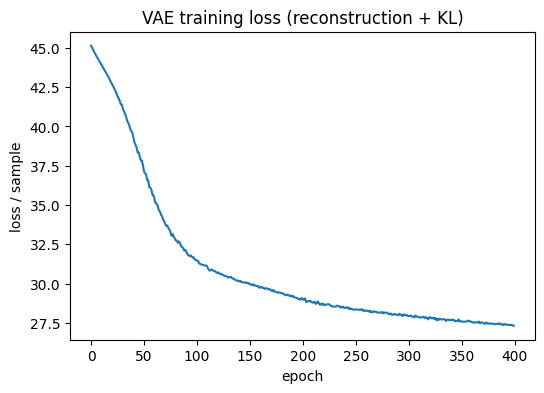

In [16]:
class VAE(nn.Module):
    def __init__(self, input_dim=64, latent_dim=2, hidden=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.fc_mu = nn.Linear(hidden, latent_dim)
        self.fc_logvar = nn.Linear(hidden, latent_dim)
        self.fc2 = nn.Linear(latent_dim, hidden)
        self.fc3 = nn.Linear(hidden, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction="sum")
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld


torch.manual_seed(SEED)
vae = VAE()
opt = optim.Adam(vae.parameters(), lr=0.001)
vae_losses = []
for _ in range(400):
    opt.zero_grad()
    recon, mu, logvar = vae(Xdig_tr)
    loss = vae_loss(recon, Xdig_tr, mu, logvar)
    loss.backward()
    opt.step()
    vae_losses.append(loss.item() / len(Xdig_tr))

plt.figure(figsize=(6, 4))
plt.plot(vae_losses)
plt.xlabel("epoch")
plt.ylabel("loss / sample")
plt.title("VAE training loss (reconstruction + KL)")
plt.show()


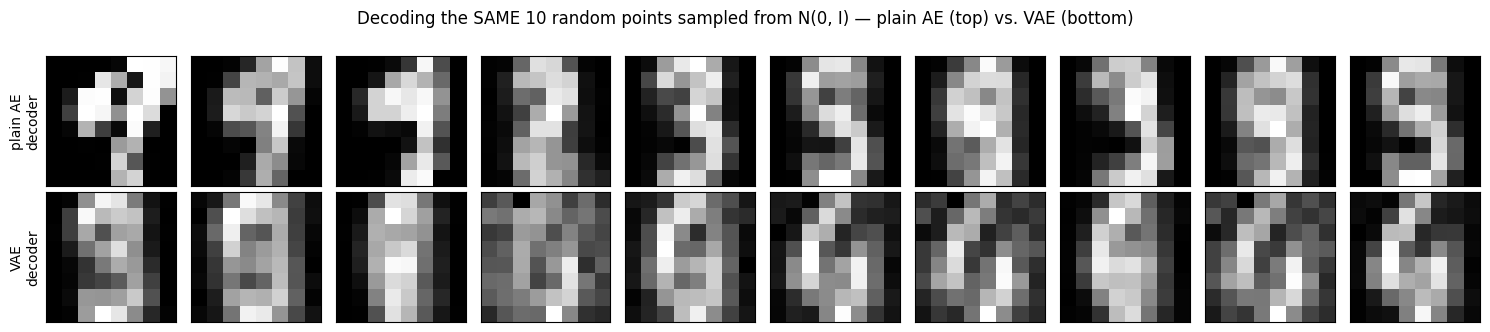

Takeaway: the plain AE was never trained to make random N(0, I) points meaningful, so its
decodes are often blurry/incoherent smears. The VAE's KL penalty explicitly shapes its whole
latent space to match N(0, I), so the same random points decode into digit-like shapes -- it
has become a (weak, low-capacity) generative model, not just a compressor.


In [17]:
torch.manual_seed(0)
random_latents = torch.randn(10, 2)  # sample directly from the N(0, I) prior

with torch.no_grad():
    ae_generated = ae.decoder(random_latents)
    vae_generated = vae.decode(random_latents)

fig, axes = plt.subplots(2, 10, figsize=(15, 3.4))
for i in range(10):
    axes[0, i].imshow(ae_generated[i].reshape(8, 8), cmap="gray")
    axes[1, i].imshow(vae_generated[i].reshape(8, 8), cmap="gray")
    for r in range(2):
        axes[r, i].set_xticks([])
        axes[r, i].set_yticks([])
axes[0, 0].set_ylabel("plain AE\ndecoder")
axes[1, 0].set_ylabel("VAE\ndecoder")
plt.suptitle("Decoding the SAME 10 random points sampled from N(0, I) — plain AE (top) vs. VAE (bottom)")
plt.tight_layout()
plt.show()

print("Takeaway: the plain AE was never trained to make random N(0, I) points meaningful, so its")
print("decodes are often blurry/incoherent smears. The VAE's KL penalty explicitly shapes its whole")
print("latent space to match N(0, I), so the same random points decode into digit-like shapes -- it")
print("has become a (weak, low-capacity) generative model, not just a compressor.")


## 11. GANs: adversarially generating the two-moons distribution

A GAN pits two networks against each other: a **generator** turns random noise into fake samples,
and a **discriminator** tries to tell those apart from real data. Both improve together. We train
one to generate points from the same two-moons distribution used in §4/§5 — a nice, visual target
because we can literally watch fake points bend from a random blob into the two crescents over
training.


In [18]:
X_real, _ = make_moons(n_samples=1000, noise=0.05, random_state=SEED)
gan_scaler = StandardScaler().fit(X_real)
X_real_t = torch.tensor(gan_scaler.transform(X_real), dtype=torch.float32)


class Generator(nn.Module):
    def __init__(self, noise_dim=8, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)


noise_dim = 8
torch.manual_seed(SEED)
G = Generator(noise_dim)
D = Discriminator()
opt_G = optim.Adam(G.parameters(), lr=2e-3, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-3, betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()

n_epochs = 3000
batch_size = 128
snapshot_epochs = [0, 300, 1000, n_epochs - 1]
snapshots = {}

for epoch in range(n_epochs):
    idx = np.random.randint(0, len(X_real_t), batch_size)
    real_batch = X_real_t[idx]
    noise = torch.randn(batch_size, noise_dim)
    fake_batch = G(noise)

    opt_D.zero_grad()
    d_real = D(real_batch)
    d_fake = D(fake_batch.detach())
    d_loss = bce(d_real, torch.ones_like(d_real)) + bce(d_fake, torch.zeros_like(d_fake))
    d_loss.backward()
    opt_D.step()

    opt_G.zero_grad()
    d_fake_for_g = D(fake_batch)
    g_loss = bce(d_fake_for_g, torch.ones_like(d_fake_for_g))
    g_loss.backward()
    opt_G.step()

    if epoch in snapshot_epochs:
        with torch.no_grad():
            snapshots[epoch] = G(torch.randn(500, noise_dim)).numpy()

print(f"Final losses -> generator: {g_loss.item():.3f}  discriminator: {d_loss.item():.3f}")
print("(a stable GAN settles with the discriminator only slightly better than chance, ~log(2)=0.69 each)")


Final losses -> generator: 0.697  discriminator: 1.380
(a stable GAN settles with the discriminator only slightly better than chance, ~log(2)=0.69 each)


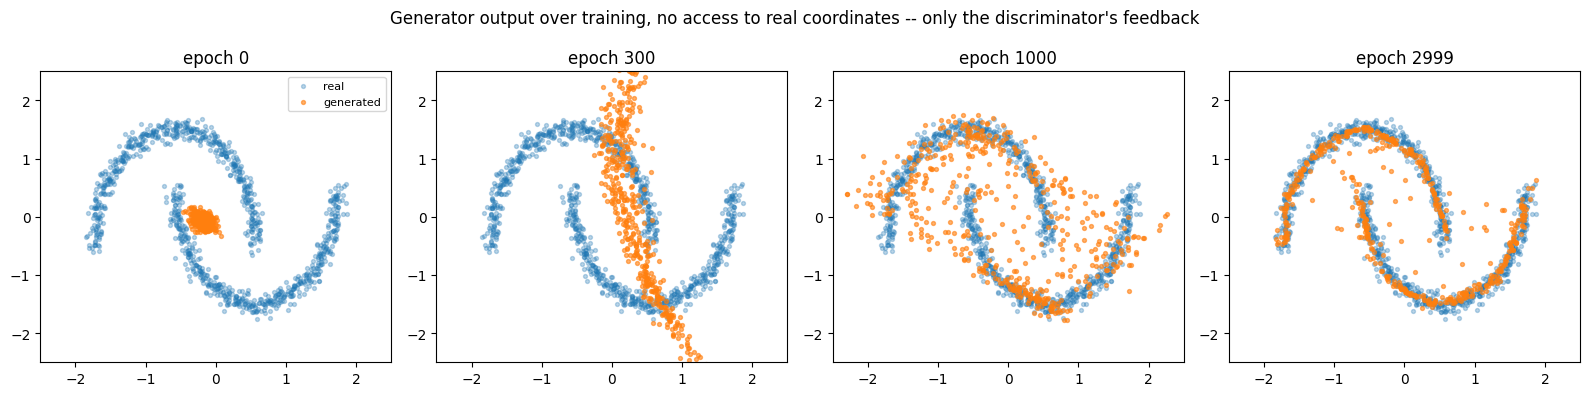

Takeaway: the generator never sees a single real (x, y) coordinate paired with its noise input --
it only ever gets a scalar 'more/less convincing' signal from the discriminator, and that alone
is enough to sculpt random noise into the two-moons shape.


In [19]:
fig, axes = plt.subplots(1, len(snapshot_epochs), figsize=(4 * len(snapshot_epochs), 4))
X_real_np = X_real_t.numpy()

for ax, epoch in zip(axes, snapshot_epochs):
    ax.scatter(X_real_np[:, 0], X_real_np[:, 1], s=8, alpha=0.3, label="real")
    ax.scatter(snapshots[epoch][:, 0], snapshots[epoch][:, 1], s=8, alpha=0.6, label="generated")
    ax.set_title(f"epoch {epoch}")
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
axes[0].legend(fontsize=8)
plt.suptitle("Generator output over training, no access to real coordinates -- only the discriminator's feedback")
plt.tight_layout()
plt.show()

print("Takeaway: the generator never sees a single real (x, y) coordinate paired with its noise input --")
print("it only ever gets a scalar 'more/less convincing' signal from the discriminator, and that alone")
print("is enough to sculpt random noise into the two-moons shape.")


## 12. Graph Neural Networks: classifying nodes from graph structure alone

A GNN generalizes convolution from a fixed grid (CNN, §6) to an arbitrary graph: each node updates
its representation by **aggregating information from its neighbors**, layer by layer. We build a
graph with 4 hidden "communities" (80 nodes total), give the model **only 12 labels total** (3 per
community — the rest are unlabeled), and give it **no node features at all**, just each node's
identity and the graph's edges. If message-passing works, information from those 12 labels should
propagate through the graph structure to correctly classify the other 68 nodes.


In [20]:
n_per_block, n_blocks = 20, 4
G_graph = nx.random_partition_graph([n_per_block] * n_blocks, p_in=0.25, p_out=0.02, seed=SEED)
block_of = np.array([G_graph.nodes[n]["block"] for n in G_graph.nodes()])
n_nodes = G_graph.number_of_nodes()

A = nx.to_numpy_array(G_graph)
A_hat = A + np.eye(n_nodes)  # add self-loops, so a node's own features survive aggregation
D_inv_sqrt = np.diag(A_hat.sum(1) ** -0.5)
A_norm = torch.tensor(D_inv_sqrt @ A_hat @ D_inv_sqrt, dtype=torch.float32)  # GCN propagation rule

X_gnn = torch.eye(n_nodes)  # featureless: only node identity, model must rely on graph structure
y_gnn = torch.tensor(block_of, dtype=torch.long)

rng3 = np.random.RandomState(SEED)
train_mask = np.zeros(n_nodes, dtype=bool)
for b in range(n_blocks):
    chosen = rng3.choice(np.where(block_of == b)[0], size=3, replace=False)
    train_mask[chosen] = True
train_mask_t = torch.tensor(train_mask)
test_mask_t = ~train_mask_t


class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, A_norm, X):
        return self.linear(A_norm @ X)  # aggregate neighbors' features, then transform


class GCN(nn.Module):
    def __init__(self, n_nodes, hidden=16, n_classes=4):
        super().__init__()
        self.gc1 = GCNLayer(n_nodes, hidden)
        self.gc2 = GCNLayer(hidden, n_classes)

    def forward(self, A_norm, X):
        h = torch.relu(self.gc1(A_norm, X))
        return self.gc2(A_norm, h)


torch.manual_seed(SEED)
gcn = GCN(n_nodes)
opt = optim.Adam(gcn.parameters(), lr=0.05, weight_decay=5e-4)
loss_fn = nn.CrossEntropyLoss()
gcn_losses = []
for _ in range(200):
    opt.zero_grad()
    logits = gcn(A_norm, X_gnn)
    loss = loss_fn(logits[train_mask_t], y_gnn[train_mask_t])
    loss.backward()
    opt.step()
    gcn_losses.append(loss.item())

with torch.no_grad():
    preds = gcn(A_norm, X_gnn).argmax(1)
test_acc = (preds[test_mask_t] == y_gnn[test_mask_t]).float().mean().item()
print(f"Labeled (training) nodes: {train_mask.sum()} / {n_nodes}")
print(f"Test accuracy on the remaining {int(test_mask_t.sum())} UNlabeled nodes: {test_acc:.1%}")


Labeled (training) nodes: 12 / 80
Test accuracy on the remaining 68 UNlabeled nodes: 94.1%


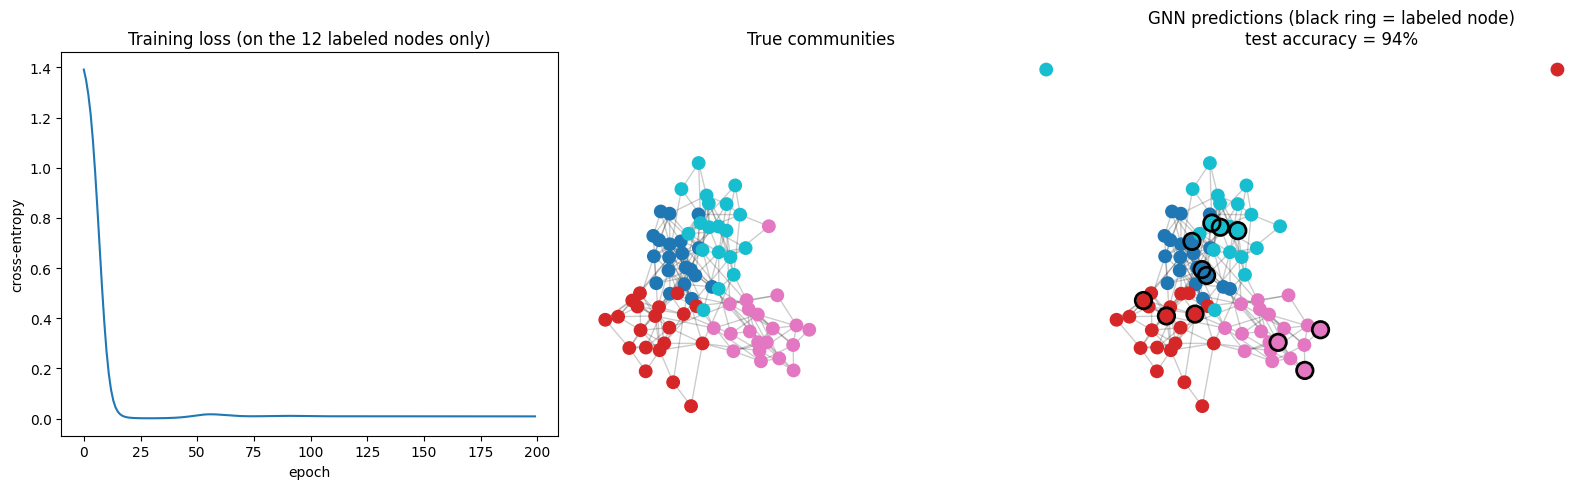

Takeaway: the model never saw a single feature describing any node, and 85% of nodes had no
label -- everything it got right came from propagating the 12 known labels through the graph's
edges via message passing, exactly the mechanism that sets GNNs apart from CNNs/MLPs.


In [21]:
pos = nx.spring_layout(G_graph, seed=SEED)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(gcn_losses)
axes[0].set_title("Training loss (on the 12 labeled nodes only)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy")

nx.draw_networkx_edges(G_graph, pos, ax=axes[1], alpha=0.2)
nx.draw_networkx_nodes(G_graph, pos, ax=axes[1], node_color=block_of, cmap="tab10", node_size=80)
axes[1].set_title("True communities")
axes[1].axis("off")

nx.draw_networkx_edges(G_graph, pos, ax=axes[2], alpha=0.2)
nx.draw_networkx_nodes(G_graph, pos, ax=axes[2], node_color=preds.numpy(), cmap="tab10", node_size=80)
nx.draw_networkx_nodes(
    G_graph, pos, ax=axes[2], nodelist=list(np.where(train_mask)[0]),
    node_color="none", edgecolors="black", linewidths=2, node_size=140,
)
axes[2].set_title(f"GNN predictions (black ring = labeled node)\ntest accuracy = {test_acc:.0%}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Takeaway: the model never saw a single feature describing any node, and 85% of nodes had no")
print("label -- everything it got right came from propagating the 12 known labels through the graph's")
print("edges via message passing, exactly the mechanism that sets GNNs apart from CNNs/MLPs.")


## 13. Embeddings: categories becoming vectors

An embedding maps a discrete category (an integer ID) to a point in a continuous vector space,
learned jointly with the task. To make the effect visible, we build a synthetic classification
task where 20 categories secretly belong to 4 underlying clusters, and only the *cluster* (not the
raw category ID) determines the label. If the embedding is learning anything useful, points from
the same true cluster should end up close together — **with no cluster information ever given to
the model directly.**


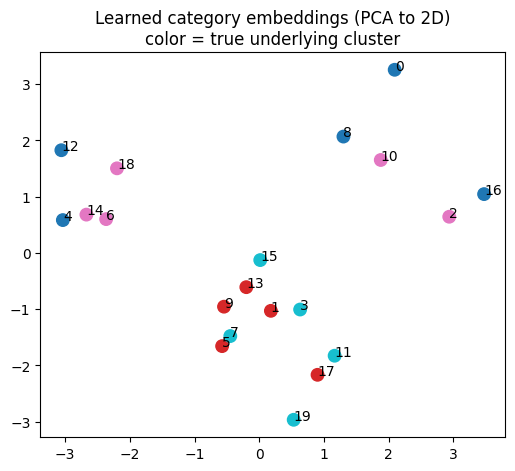

Takeaway: category IDs are arbitrary integers with no inherent notion of 'distance' -- yet
after training, categories from the same true cluster land near each other in vector space.
This is what lets 'similar' words/products/users end up with similar embeddings in practice.


In [22]:
n_categories = 20
n_clusters = 4
cluster_of = np.arange(n_categories) % n_clusters

rng2 = np.random.RandomState(SEED)
n_samples_emb = 2000
cats = rng2.randint(0, n_categories, size=n_samples_emb)
labels = (cluster_of[cats] % 2).astype(np.float32)  # label depends only on the cluster

cats_t = torch.tensor(cats, dtype=torch.long)
labels_t = torch.tensor(labels).unsqueeze(1)


class EmbeddingClassifier(nn.Module):
    def __init__(self, n_categories, embed_dim=8):
        super().__init__()
        self.embedding = nn.Embedding(n_categories, embed_dim)
        self.head = nn.Sequential(nn.Linear(embed_dim, 16), nn.ReLU(), nn.Linear(16, 1))

    def forward(self, x):
        return self.head(self.embedding(x))


torch.manual_seed(SEED)
emb_model = EmbeddingClassifier(n_categories)
opt = optim.Adam(emb_model.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()
for _ in range(300):
    opt.zero_grad()
    loss = loss_fn(emb_model(cats_t), labels_t)
    loss.backward()
    opt.step()

with torch.no_grad():
    vectors = emb_model.embedding.weight.numpy()
vectors_2d = PCA(n_components=2, random_state=SEED).fit_transform(vectors)

plt.figure(figsize=(6, 5))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=cluster_of, cmap="tab10", s=80)
for i in range(n_categories):
    plt.annotate(str(i), (vectors_2d[i, 0], vectors_2d[i, 1]))
plt.title("Learned category embeddings (PCA to 2D)\ncolor = true underlying cluster")
plt.show()

print("Takeaway: category IDs are arbitrary integers with no inherent notion of 'distance' -- yet")
print("after training, categories from the same true cluster land near each other in vector space.")
print("This is what lets 'similar' words/products/users end up with similar embeddings in practice.")


## 14. Recap

| Section | Cheat sheet concept | What the takeaway showed |
|---|---|---|
| 2 | Activation functions | Sigmoid/tanh saturate → vanishing gradients; ReLU doesn't |
| 3 | Bias–variance trade-off | Underfit / good fit / overfit, quantified via the train–test error gap |
| 4 | Batch vs. online learning | Same epochs, very different # of updates and convergence speed |
| 5 | Feedforward NN (FNN/MLP) | More hidden layers → tighter, more accurate decision boundary |
| 6 | Convolutional NN (CNN) | Learned filters act as reusable local pattern detectors |
| 7 | RNN / LSTM / GRU | Gates let gradients (and signal) survive ~60-step-long dependencies |
| 8 | Transformers (self-attention) | Trained attention weights concentrate on the provably-correct position |
| 9 | Autoencoders | 64 pixels compressed to 2 numbers and reconstructed |
| 10 | Variational autoencoders | VAE's prior makes *any* sampled latent point decodable; plain AE's doesn't |
| 11 | GANs | Adversarial feedback alone sculpts noise into the two-moons shape |
| 12 | Graph Neural Networks | 12 labels propagate through graph structure to classify 68 unlabeled nodes |
| 13 | Embeddings | Category → vector; same true cluster ended up close in space |

See [`ANN_Cheatsheet.md`](ANN_Cheatsheet.md) for the conceptual map this notebook implements.
